In [2]:
import requests
import pandas as pd

In [5]:
# Plant 1 approximate location
LATITUDE = 14.9185
LONGITUDE = 78.2867

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": "2024-05-15",
    "end_date": "2026-07-24",
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "shortwave_radiation",
        "wind_speed_10m"
    ]),
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

weather_df = pd.DataFrame(data["hourly"])

weather_df.to_csv(
    "source_A_open_meteo.csv",
    index=False
)

print(weather_df.head())
print(weather_df.shape)

               time  temperature_2m  relative_humidity_2m  cloud_cover  \
0  2024-05-15T00:00            29.6                    57            0   
1  2024-05-15T01:00            29.0                    61            7   
2  2024-05-15T02:00            28.6                    65           27   
3  2024-05-15T03:00            28.0                    68           25   
4  2024-05-15T04:00            27.2                    67           20   

   shortwave_radiation  wind_speed_10m  
0                  0.0            10.8  
1                  0.0             8.2  
2                  0.0             7.4  
3                  0.0             8.7  
4                  0.0             7.9  
(19224, 6)


In [1]:
import pandas as pd
import numpy as np

In [14]:
generation = pd.read_csv("Plant_1_Generation_Data_2024-2026.csv")

print(generation.head())
print(generation.shape)
print(generation.columns)

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2024 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2024 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2024 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2024 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2024 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD   TOTAL_YIELD  
0          0.0  1.330738e+07  
1          0.0  1.398402e+07  
2          0.0  1.478015e+07  
3          0.0  1.521595e+07  
4          0.0  1.495182e+07  
(422928, 7)
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')


In [15]:
generation["DATE_TIME"] = pd.to_datetime(
    generation["DATE_TIME"],
    format="%d-%m-%Y %H:%M"
)

# First: all inverters → plant-level AC power
plant_power = (
    generation
    .groupby("DATE_TIME")["AC_POWER"]
    .sum()
    .reset_index()
)

# Second: 15-minute → hourly average power
plant_hourly = (
    plant_power
    .set_index("DATE_TIME")
    .resample("1h")
    .mean()
    .reset_index()
)

plant_hourly.head()

,DATE_TIME,AC_POWER
0,2024-05-15 00:00:00,0.0
1,2024-05-15 01:00:00,0.0
2,2024-05-15 02:00:00,0.0
3,2024-05-15 03:00:00,0.0
4,2024-05-15 04:00:00,0.0


In [16]:
weather = pd.read_csv("source_A_open_meteo.csv")

print(weather.head())
print(weather.columns)

               time  temperature_2m  relative_humidity_2m  cloud_cover  \
0  2024-05-15T00:00            29.6                    57            0   
1  2024-05-15T01:00            29.0                    61            7   
2  2024-05-15T02:00            28.6                    65           27   
3  2024-05-15T03:00            28.0                    68           25   
4  2024-05-15T04:00            27.2                    67           20   

   shortwave_radiation  wind_speed_10m  
0                  0.0            10.8  
1                  0.0             8.2  
2                  0.0             7.4  
3                  0.0             8.7  
4                  0.0             7.9  
Index(['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover',
       'shortwave_radiation', 'wind_speed_10m'],
      dtype='object')


In [17]:
print(weather.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'shortwave_radiation', 'wind_speed_10m']


In [18]:
weather.columns = weather.columns.str.strip()

print(weather.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'shortwave_radiation', 'wind_speed_10m']


In [22]:
weather["time"] = pd.to_datetime(weather["time"])

weather = weather.rename(
    columns={"time": "DATE_TIME"}
)

print(weather.columns.tolist())
print(weather["DATE_TIME"].min())
print(weather["DATE_TIME"].max())

['DATE_TIME', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'shortwave_radiation', 'wind_speed_10m']
2024-05-15 00:00:00
2026-07-24 23:00:00


In [23]:
print(weather.head())
print(weather.columns.tolist())

            DATE_TIME  temperature_2m  relative_humidity_2m  cloud_cover  \
0 2024-05-15 00:00:00            29.6                    57            0   
1 2024-05-15 01:00:00            29.0                    61            7   
2 2024-05-15 02:00:00            28.6                    65           27   
3 2024-05-15 03:00:00            28.0                    68           25   
4 2024-05-15 04:00:00            27.2                    67           20   

   shortwave_radiation  wind_speed_10m  
0                  0.0            10.8  
1                  0.0             8.2  
2                  0.0             7.4  
3                  0.0             8.7  
4                  0.0             7.9  
['DATE_TIME', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'shortwave_radiation', 'wind_speed_10m']


In [24]:
print("Weather:")
print(weather["DATE_TIME"].min())
print(weather["DATE_TIME"].max())

print("\nGeneration:")
print(generation["DATE_TIME"].min())
print(generation["DATE_TIME"].max())

Weather:
2024-05-15 00:00:00
2026-07-24 23:00:00

Generation:
2024-05-15 00:00:00
2026-07-24 23:00:00


In [25]:
# ==========================================
# STEP 1: Prepare Source B
# ==========================================

generation["DATE_TIME"] = pd.to_datetime(generation["DATE_TIME"])

# Check columns
print("Generation columns:")
print(generation.columns.tolist())

print("\nGeneration shape:")
print(generation.shape)

Generation columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

Generation shape:
(422928, 7)


In [26]:
# ==========================================
# STEP 2: Convert 15-minute generation
#         into hourly generation
# ==========================================

generation_hourly = (
    generation
    .set_index("DATE_TIME")
    .resample("1h")
    .agg({
        "AC_POWER": "mean",
        "DC_POWER": "mean",
        "DAILY_YIELD": "last",
        "TOTAL_YIELD": "last"
    })
    .reset_index()
)

print("Hourly generation:")
print(generation_hourly.head())

print("\nShape:")
print(generation_hourly.shape)

print("\nDate range:")
print(generation_hourly["DATE_TIME"].min())
print(generation_hourly["DATE_TIME"].max())

Hourly generation:
            DATE_TIME  AC_POWER  DC_POWER  DAILY_YIELD   TOTAL_YIELD
0 2024-05-15 00:00:00       0.0       0.0          0.0  1.483092e+07
1 2024-05-15 01:00:00       0.0       0.0          0.0  1.483092e+07
2 2024-05-15 02:00:00       0.0       0.0          0.0  1.483092e+07
3 2024-05-15 03:00:00       0.0       0.0          0.0  1.483092e+07
4 2024-05-15 04:00:00       0.0       0.0          0.0  1.483092e+07

Shape:
(19224, 5)

Date range:
2024-05-15 00:00:00
2026-07-24 23:00:00


In [27]:
# ==========================================
# STEP 3: Merge Weather + Generation
# ==========================================

weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])
generation_hourly["DATE_TIME"] = pd.to_datetime(
    generation_hourly["DATE_TIME"]
)

training_dataset = pd.merge(
    weather,
    generation_hourly,
    on="DATE_TIME",
    how="inner"
)

print("Training Dataset:")
print(training_dataset.head())

print("\nShape:")
print(training_dataset.shape)

print("\nDate range:")
print(training_dataset["DATE_TIME"].min())
print(training_dataset["DATE_TIME"].max())

Training Dataset:
            DATE_TIME  temperature_2m  relative_humidity_2m  cloud_cover  \
0 2024-05-15 00:00:00            29.6                    57            0   
1 2024-05-15 01:00:00            29.0                    61            7   
2 2024-05-15 02:00:00            28.6                    65           27   
3 2024-05-15 03:00:00            28.0                    68           25   
4 2024-05-15 04:00:00            27.2                    67           20   

   shortwave_radiation  wind_speed_10m  AC_POWER  DC_POWER  DAILY_YIELD  \
0                  0.0            10.8       0.0       0.0          0.0   
1                  0.0             8.2       0.0       0.0          0.0   
2                  0.0             7.4       0.0       0.0          0.0   
3                  0.0             8.7       0.0       0.0          0.0   
4                  0.0             7.9       0.0       0.0          0.0   

    TOTAL_YIELD  
0  1.483092e+07  
1  1.483092e+07  
2  1.483092e+07  
3 

In [28]:
# ==========================================
# STEP 4: Save Training Dataset
# ==========================================

training_dataset.to_csv(
    "training_dataset.csv",
    index=False
)

print("✅ training_dataset.csv created successfully!")
print(f"Total records: {len(training_dataset):,}")

✅ training_dataset.csv created successfully!
Total records: 19,224


In [29]:
# ==========================================
# STEP 5: Load & Check Training Dataset
# ==========================================

import pandas as pd
import numpy as np

df = pd.read_csv("training_dataset.csv")

df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print(df["DATE_TIME"].min())
print(df["DATE_TIME"].max())

df.head()

Shape: (19224, 10)

Columns:
['DATE_TIME', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'shortwave_radiation', 'wind_speed_10m', 'AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']

Missing values:
DATE_TIME               0
temperature_2m          0
relative_humidity_2m    0
cloud_cover             0
shortwave_radiation     0
wind_speed_10m          0
AC_POWER                0
DC_POWER                0
DAILY_YIELD             0
TOTAL_YIELD             0
dtype: int64

Date range:
2024-05-15 00:00:00
2026-07-24 23:00:00


,DATE_TIME,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,wind_speed_10m,AC_POWER,DC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2024-05-15 00:00:00,29.6,57,0,0.0,10.8,0.0,0.0,0.0,1.483092e+07
1,2024-05-15 01:00:00,29.0,61,7,0.0,8.2,0.0,0.0,0.0,1.483092e+07
2,2024-05-15 02:00:00,28.6,65,27,0.0,7.4,0.0,0.0,0.0,1.483092e+07
3,2024-05-15 03:00:00,28.0,68,25,0.0,8.7,0.0,0.0,0.0,1.483092e+07
4,2024-05-15 04:00:00,27.2,67,20,0.0,7.9,0.0,0.0,0.0,1.483092e+07


In [31]:
# ==========================================
# STEP 6 + STEP 7
# Feature Engineering + Select Features
# ==========================================

import pandas as pd
import numpy as np

# Make sure DATE_TIME is datetime
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

# ------------------------------------------
# Time-based features
# ------------------------------------------

df["hour"] = df["DATE_TIME"].dt.hour
df["month"] = df["DATE_TIME"].dt.month
df["day_of_year"] = df["DATE_TIME"].dt.dayofyear
df["day_of_week"] = df["DATE_TIME"].dt.dayofweek

# ------------------------------------------
# Cyclic features
# ------------------------------------------

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

# ------------------------------------------
# Features for ML
# ------------------------------------------

features = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "shortwave_radiation",
    "wind_speed_10m",
    "hour",
    "month",
    "day_of_year",
    "day_of_week",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

# Target
target = "AC_POWER"

# ------------------------------------------
# Create X and y
# ------------------------------------------

X = df[features].copy()
y = df[target].copy()

print("✅ Feature engineering completed!")

print("\nFeatures:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

✅ Feature engineering completed!

Features:
['temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'shortwave_radiation', 'wind_speed_10m', 'hour', 'month', 'day_of_year', 'day_of_week', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

X shape: (19224, 13)
y shape: (19224,)

First 5 rows of X:


,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,wind_speed_10m,hour,month,day_of_year,day_of_week,hour_sin,hour_cos,day_sin,day_cos
0,29.6,57,0,0.0,10.8,0,5,136,2,0.000000,1.000000,0.718792,-0.695225
1,29.0,61,7,0.0,8.2,1,5,136,2,0.258819,0.965926,0.718792,-0.695225
2,28.6,65,27,0.0,7.4,2,5,136,2,0.500000,0.866025,0.718792,-0.695225
3,28.0,68,25,0.0,8.7,3,5,136,2,0.707107,0.707107,0.718792,-0.695225
4,27.2,67,20,0.0,7.9,4,5,136,2,0.866025,0.500000,0.718792,-0.695225



First 5 target values:


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: AC_POWER, dtype: float64

In [32]:
# ==========================================
# STEP 8: Time-Based Train/Test Split
# ==========================================

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("✅ Train/Test split completed!")

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining period:")
print(df["DATE_TIME"].iloc[0])
print("to")
print(df["DATE_TIME"].iloc[split_index - 1])

print("\nTesting period:")
print(df["DATE_TIME"].iloc[split_index])
print("to")
print(df["DATE_TIME"].iloc[-1])

✅ Train/Test split completed!

Training records: 15379
Testing records: 3845

Training period:
2024-05-15 00:00:00
to
2026-02-14 18:00:00

Testing period:
2026-02-14 19:00:00
to
2026-07-24 23:00:00


In [33]:
# ==========================================
# STEP 9: Train XGBoost Model
# ==========================================

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("✅ XGBoost model trained successfully!")

✅ XGBoost model trained successfully!


In [34]:
# ==========================================
# STEP 10: Evaluate Model
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("================================")
print("      MODEL PERFORMANCE")
print("================================")

print(f"MAE  : {mae:.2f} kW")
print(f"RMSE : {rmse:.2f} kW")
print(f"R²   : {r2:.4f}")
print(f"R² % : {r2 * 100:.2f}%")

      MODEL PERFORMANCE
MAE  : 60.35 kW
RMSE : 120.51 kW
R²   : 0.9115
R² % : 91.15%


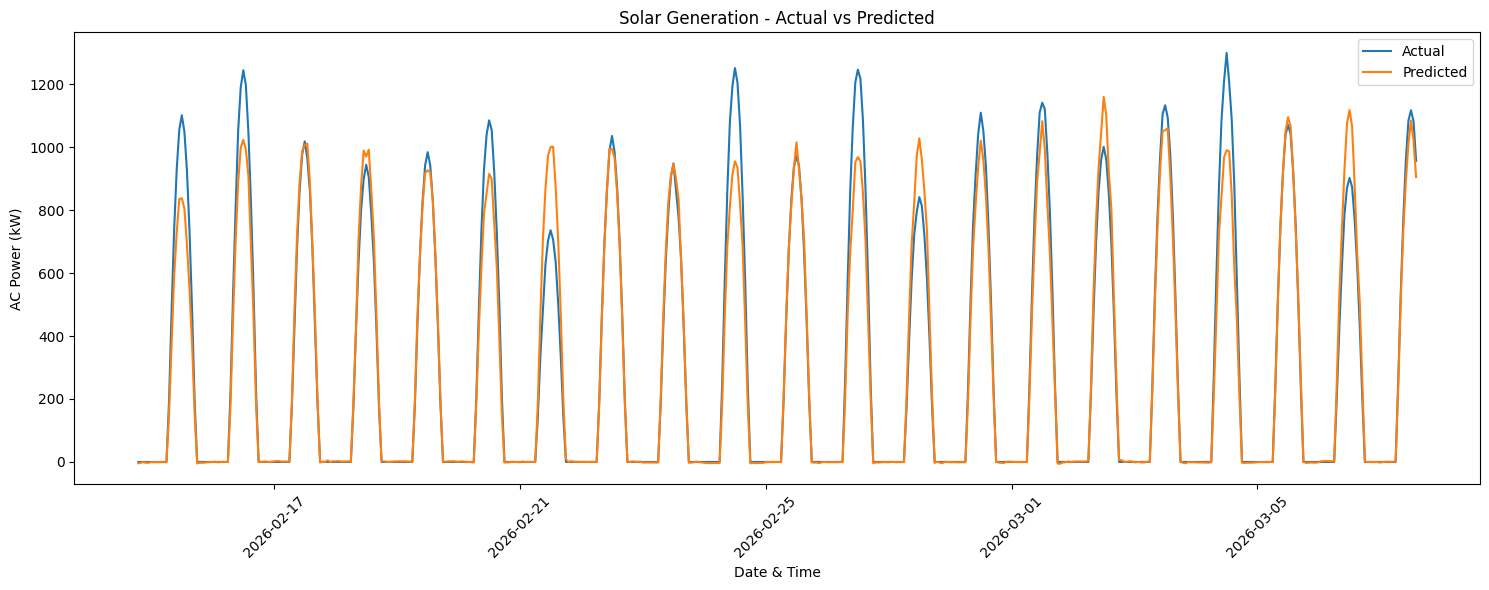

In [35]:
# ==========================================
# STEP 11: Actual vs Predicted
# ==========================================

import matplotlib.pyplot as plt

results = pd.DataFrame({
    "DATE_TIME": df["DATE_TIME"].iloc[split_index:].values,
    "Actual_AC_POWER": y_test.values,
    "Predicted_AC_POWER": y_pred
})

# First 500 test records
plot_data = results.iloc[:500]

plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["DATE_TIME"],
    plot_data["Actual_AC_POWER"],
    label="Actual"
)

plt.plot(
    plot_data["DATE_TIME"],
    plot_data["Predicted_AC_POWER"],
    label="Predicted"
)

plt.xlabel("Date & Time")
plt.ylabel("AC Power (kW)")
plt.title("Solar Generation - Actual vs Predicted")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 Feature  Importance
10              hour_cos    0.729632
3    shortwave_radiation    0.083466
6                  month    0.069611
5                   hour    0.030192
11               day_sin    0.027752
12               day_cos    0.021731
7            day_of_year    0.013333
8            day_of_week    0.007428
4         wind_speed_10m    0.004626
0         temperature_2m    0.004418
2            cloud_cover    0.003856
1   relative_humidity_2m    0.003179
9               hour_sin    0.000775


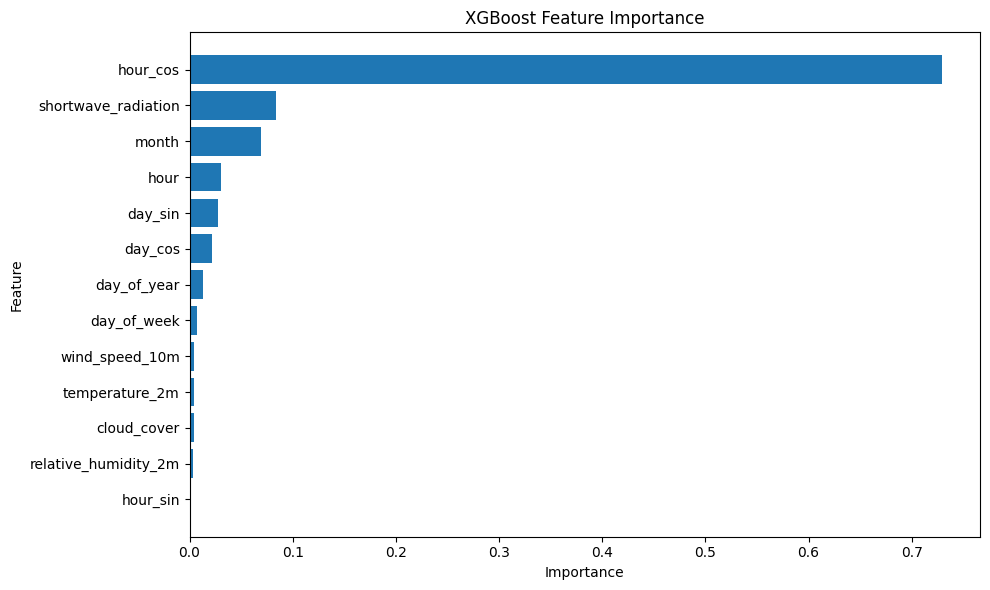

In [36]:
# ==========================================
# STEP 12: Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [37]:
# ==========================================
# STEP 13: Save Trained Model
# ==========================================

import joblib

joblib.dump(
    model,
    "solar_generation_xgboost_model.pkl"
)

joblib.dump(
    features,
    "model_features.pkl"
)

print("✅ Model saved successfully!")
print("📁 solar_generation_xgboost_model.pkl")
print("📁 model_features.pkl")

✅ Model saved successfully!
📁 solar_generation_xgboost_model.pkl
📁 model_features.pkl


In [38]:
# ==========================================
# MODEL ACCURACY / PERFORMANCE
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict test data
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========================================")
print("       SOLAR FORECAST MODEL RESULTS")
print("========================================")

print(f"MAE       : {mae:.2f} kW")
print(f"RMSE      : {rmse:.2f} kW")
print(f"R²        : {r2:.4f}")
print(f"R² Score  : {r2 * 100:.2f}%")

# Approximate accuracy based on MAE
mean_actual = y_test.mean()
approx_accuracy = max(0, 100 * (1 - mae / mean_actual))

print(f"Approx. Accuracy : {approx_accuracy:.2f}%")

       SOLAR FORECAST MODEL RESULTS
MAE       : 60.35 kW
RMSE      : 120.51 kW
R²        : 0.9115
R² Score  : 91.15%
Approx. Accuracy : 81.48%
